In [2]:
import torch
torch.where(torch.tensor([[1, 0, 1, 0, 1]]) == 1)

(tensor([0, 0, 0]), tensor([0, 2, 4]))

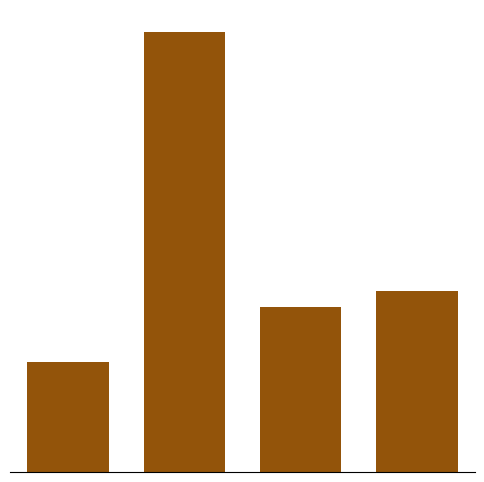

In [9]:
import matplotlib.pyplot as plt

# values = [3, 5, 2, 4]
values = [2, 8, 3, 3.3]
x = [0, 1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 6))  # 1:1 正方形

ax.bar(
    x, values,
    width=0.7,
    color="#93540A"
)

for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("black")

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xlim(-0.5, 3.5)

plt.show()

In [5]:
import torch

A = torch.tensor([1, 2, 3, 2, 4, 2, 2, 6])
B = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8])

# 1. 找 mask
mask = (A == 2)

# 2. 每个位置的重复次数
repeat_times = torch.ones_like(A)
repeat_times[mask] = 2

# 3. 扩展 A 和 B
A_expanded = torch.repeat_interleave(A, repeat_times)
B_expanded = torch.repeat_interleave(B, repeat_times)

# 4. 计算扩展后 index
# 原始 index
idx = torch.arange(len(A))

# 每个位置之前一共插入了多少个额外元素
offset = torch.cumsum(repeat_times - 1, dim=0)

# 只取 mask 位置的最终 index
expanded_idx = idx[mask] + offset[mask]

print(A_expanded)   # tensor([1, 2, 2, 3, 2, 2, 4])
print(B_expanded)   # tensor([1, 2, 2, 3, 4, 4, 5])
print(expanded_idx) # tensor([1, 4])

tensor([1, 2, 2, 3, 2, 2, 4, 2, 2, 2, 2, 6])
tensor([1, 2, 2, 3, 4, 4, 5, 6, 6, 7, 7, 8])
tensor([ 2,  5,  8, 10])


In [ ]:
import numpy as np
asym_robust_sums = clipped_selected.sum(axis=1)
clipped_energy = np.square(clipped_selected).sum(axis=1)
z_scores = asym_robust_sums / np.sqrt(clipped_energy + self.robust_eps)
phi_scores = 0.5 * (1.0 + np.vectorize(math.erf)(z_scores / math.sqrt(2.0)))
score_center = float(phi_scores.mean())
softmax_logits = self.subset_pool_beta * (phi_scores - score_center)
softmax_logits = softmax_logits - np.max(softmax_logits)
softmax_weights = np.exp(softmax_logits)
softmax_weights = softmax_weights / softmax_weights.sum()
pooled_score = float(np.sum(softmax_weights * phi_scores))
comparisons = phi_scores > 0.5